# EDA: Yandex Maps Relevance Dataset

**Purpose of this notebook:** answer exactly three project questions through data analysis and produce ready-to-use training artefacts for the Baseline model.

| # | Question | Answered in |
|---|----------|-------------|
| Q1 | How many classes to use when training the baseline? What to do with class 0.1? | §3, §4 |
| Q2 | How to split the cleaned data for valid validation and test evaluation? | §5 |
| Q3 | Which rows with missing fields should be routed to the agent? | §6 |

Every section ends with a **Decision** box backed by empirical evidence.  
§7 prepares the final artefacts consumed by the Baseline training pipeline.

## 0. Setup

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import chi2_contingency
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# ── project imports ────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()          # ipynb location
BASE_DIR     = NOTEBOOK_DIR.parent       # project root

if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

from utils.config import (
    COL_ID, COL_QUERY, COL_NAME, COL_ADDRESS,
    COL_RUBRIC, COL_RELEVANCE, COL_REVIEWS, COL_PRICELIST,
    COL_COMBINED_TEXT, KEEP_COLS, LABEL_NAMES_BINARY, LABEL_MAP_BINARY, TARGET,
    DATA_PATH, PROCESSED_DATA_DIR, EDA_REPORTS_DIR as _EDA_REPORTS_DIR,
    RANDOM_STATE, create_directories
)

from utils.data_loader import load_dataset


# ── output directory ───────────────────────────────────────────────────────
create_directories()
EDA_REPORTS_DIR = Path(_EDA_REPORTS_DIR)

# ── plot style ─────────────────────────────────────────────────────────────
PAPER_STYLE = {
    "figure.figsize": (7, 4),
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.size": 11,
    "savefig.bbox": "tight",
}

rcParams.update(PAPER_STYLE)
sns.set_theme(style="whitegrid", context="paper")

def paper_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10, weight='bold')
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    return ax

pd.options.display.float_format = "{:.4f}".format

LABEL_ORDER = [0.0, 0.1, 1.0]
LABEL_NAMES = {0.0: 'IRRELEVANT (0)', 0.1: 'REL_MINUS (0.1)', 1.0: 'RELEVANT (1)'}
PALETTE     = {0.0: '#E74C3C', 0.1: '#F39C12', 1.0: '#2ECC71'}

pd.set_option('display.max_colwidth', 120)
print('Setup complete.')

Setup complete.


## 1. Load & clean

In [2]:
df_raw = pd.read_json(DATA_PATH, lines=True)
df_raw.columns = df_raw.columns.str.lower()
print(f'Raw shape: {df_raw.shape}')

Raw shape: (35094, 8)


In [3]:
print("Columns:")
for col in df_raw.columns:
    print("-", col)
print("\nData types:")
display(df_raw.dtypes)

Columns:
- text
- address
- name
- normalized_main_rubric_name_ru
- permalink
- prices_summarized
- relevance
- reviews_summarized

Data types:


text                               object
address                            object
name                               object
normalized_main_rubric_name_ru     object
permalink                           int64
prices_summarized                  object
relevance                         float64
reviews_summarized                 object
dtype: object

In [4]:
duplicate_count = df_raw.duplicated().sum()
print(f"Exact duplicates: {duplicate_count}")

Exact duplicates: 0


In [5]:
contradictory = (
    df_raw.groupby([COL_QUERY, COL_ID])[COL_RELEVANCE]
    .nunique()
    .reset_index()
)
contradictory = contradictory[contradictory[COL_RELEVANCE] > 1]
print(f"Potential contradictory groups: {len(contradictory)}")
display(contradictory.head())

Potential contradictory groups: 5


,text,permalink,relevance
12140,доставка еды,1333655057,2
20161,мясной ресторан москва,1172753132,2
20983,необычные кафе москвы,181341690685,2
33845,чебуречная,1105048178,2
33849,чебуречная,7647271812,2


In [6]:
df_raw[df_raw.duplicated(subset=[COL_QUERY, COL_ID], keep=False)]

,text,address,name,normalized_main_rubric_name_ru,permalink,prices_summarized,relevance,reviews_summarized
9067,чебуречная,"Москва, Ярославская улица, 9Б",Чебуреки; Chebureki; Nika-Vek XXI; Ника-Век XXI,Быстрое питание,1105048178,None,1.0000,"Организация занимается продажей чебуреков, придерживаясь стиля и вкуса советской эпохи. Отзывы в основном положитель..."
9068,чебуречная,"Москва, Ярославская улица, 9Б",Чебуреки; Chebureki; Nika-Vek XXI; Ника-Век XXI,Быстрое питание,1105048178,None,0.0000,"Организация занимается продажей чебуреков, придерживаясь стиля и вкуса советской эпохи. Отзывы в основном положитель..."
12731,чебуречная,"Москва, улица Арбат, 44с1",Чебуречная СССР; Cheburechnaya Ussr; СССР,Кафе,7647271812,"Чебуречная СССР предлагает различные чебуреки, блюда русской кухни, салаты, закуски и десерты, а также напитки и соу...",1.0000,"Организация занимается подачей блюд быстрого питания в стиле СССР, особое внимание уделяется чебурекам. Отзывы смеша..."
12732,чебуречная,"Москва, улица Арбат, 44с1",Чебуречная СССР; Cheburechnaya Ussr; СССР,Кафе,7647271812,"Чебуречная СССР предлагает различные чебуреки, блюда русской кухни, салаты, закуски и десерты, а также напитки и соу...",0.0000,"Организация занимается подачей блюд быстрого питания в стиле СССР, особое внимание уделяется чебурекам. Отзывы смеша..."
18268,мясной ресторан москва,"Москва, улица Балчуг, 1",Балчуг Гриль; The Baltschug Grill; Baltschug Kempinski; Lobby Lounge; Балчуг; Балчуг гриль; Балчуг-гриль; Лобби Лаун...,Ресторан,1172753132,Ресторан предлагает различные гастрономические мероприятия и завтраки с живописным видом | пасхальный бранч | завтра...,0.0000,"Организация занимается ресторанным обслуживанием, в частности предлагает завтраки. Тональность отзывов преимуществен..."
18269,мясной ресторан москва,"Москва, улица Балчуг, 1",Балчуг Гриль; The Baltschug Grill; Baltschug Kempinski; Lobby Lounge; Балчуг; Балчуг гриль; Балчуг-гриль; Лобби Лаун...,Ресторан,1172753132,Ресторан предлагает различные гастрономические мероприятия и завтраки с живописным видом | пасхальный бранч | завтра...,1.0000,"Организация занимается ресторанным обслуживанием, в частности предлагает завтраки. Тональность отзывов преимуществен..."
25975,необычные кафе москвы,"Москва, Бродников переулок, 8",Квартира 44; Kvartira 44; Кафе-бар Кв 44; Kafe-bar Kv 44,Кафе,181341690685,Ресторан «Квартира 44» предлагает разнообразные блюда: от классических салатов и супов до изысканных горячих блюд и ...,1.0000,"Организация «Квартира 44» — это кафе с банкетным залом, известное своей атмосферой и живой музыкой. Тональность отзы..."
25976,необычные кафе москвы,"Москва, Бродников переулок, 8",Квартира 44; Kvartira 44; Кафе-бар Кв 44; Kafe-bar Kv 44,Кафе,181341690685,Ресторан «Квартира 44» предлагает разнообразные блюда: от классических салатов и супов до изысканных горячих блюд и ...,0.0000,"Организация «Квартира 44» — это кафе с банкетным залом, известное своей атмосферой и живой музыкой. Тональность отзы..."
33334,доставка еды,"Москва, Большая Дорогомиловская улица, 12А",Батони; Batoni; Кафе Батони; Ресторан Батони,Кафе,1333655057,"Кафе и ресторан «Батони» предлагает разнообразные супы, салаты, горячие блюда, десерты и соусы, а также доставку еды...",0.1000,"Организация занимается грузинской кухней, имеет ресторан и предлагает доставку еды. Отзывы в основном положительные:..."
33335,доставка еды,"Москва, Большая Дорогомиловская улица, 12А",Батони; Batoni; Кафе Батони; Ресторан Батони,Кафе,1333655057,"Кафе и ресторан «Батони» предлагает разнообразные супы, салаты, горячие блюда, десерты и соусы, а также доставку еды...",0.0000,"Организация занимается грузинской кухней, имеет ресторан и предлагает доставку еды. Отзывы в основном положительные:..."


We identified 5 potentially contradictory annotations where identical query-organisation pairs received different labels. These cases may indicate annotation inconsistency, ambiguous intent, or insufficient context. For now we remove it from the dataset. It should be given to annotators for checking. 

In [7]:
NOISE_INDICES = [9068, 12732, 18268, 25976, 33335]
df = df_raw.drop(index=NOISE_INDICES).reset_index(drop=True)
print(f'After removing {len(NOISE_INDICES)} noisy duplicates: {df.shape}')

After removing 5 noisy duplicates: (35089, 8)


## 2. Dataset overview
A concise snapshot of what we are working with.

In [8]:
# ── 2.1 Missing values ─────────────────────────────────────────────────────
miss     = df.isnull().sum()
miss_pct = miss / len(df) * 100
miss_df  = pd.DataFrame({'missing_n': miss, 'missing_%': miss_pct.round(1)})
print('Missing values per column:')
print(miss_df[miss_df.missing_n > 0].to_string())

# ── 2.2 Binary presence flags ──────────────────────────────────────────────
df['has_reviews']   = df[COL_REVIEWS].notna()
df['has_pricelist'] = df[COL_PRICELIST].notna()

n_both_missing = (~df['has_reviews'] & ~df['has_pricelist']).sum()
print(f'\nRows missing BOTH reviews and pricelist: {n_both_missing} ({n_both_missing/len(df)*100:.1f}%)')

Missing values per column:
                    missing_n  missing_%
prices_summarized       14464    41.2000
reviews_summarized       1539     4.4000

Rows missing BOTH reviews and pricelist: 1398 (4.0%)


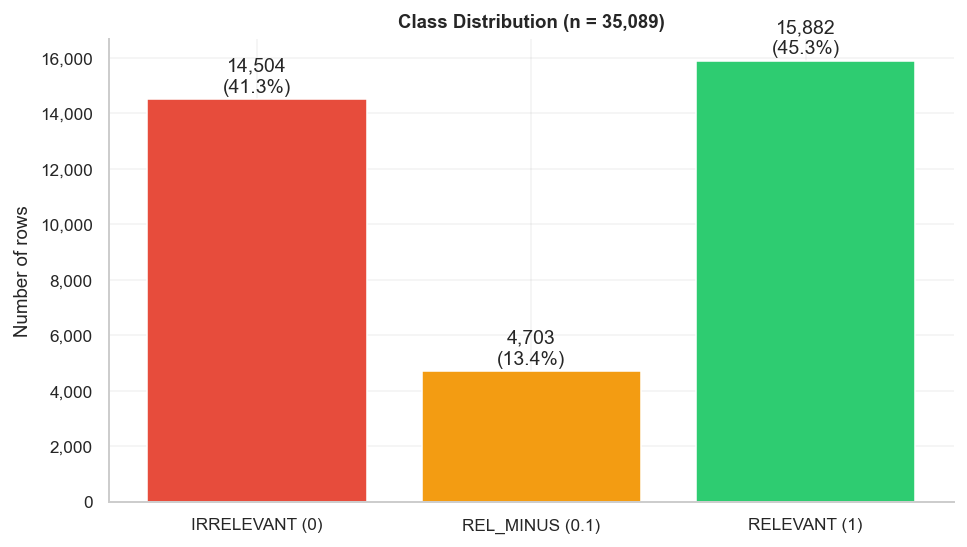

Saved → eda_reports/fig1_class_distribution.png


In [9]:
# ── 2.3 Class distribution bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
counts = df[COL_RELEVANCE].value_counts().sort_index()
bars = ax.bar(
    [LABEL_NAMES[k] for k in counts.index],
    counts.values,
    color=[PALETTE[k] for k in counts.index],
    edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 120,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Class Distribution (n = {:,})'.format(len(df)), fontweight='bold')
ax.set_ylabel('Number of rows')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig1_class_distribution.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig1_class_distribution.png')

## 3. Missing fields vs. class — deciding what to do with NaN rows

**Key question:** are missing `reviews_summarized` and `prices_summarized`
systematically associated with a particular relevance class?
If yes — missing fields may be an informative signal for the agent routing decision.

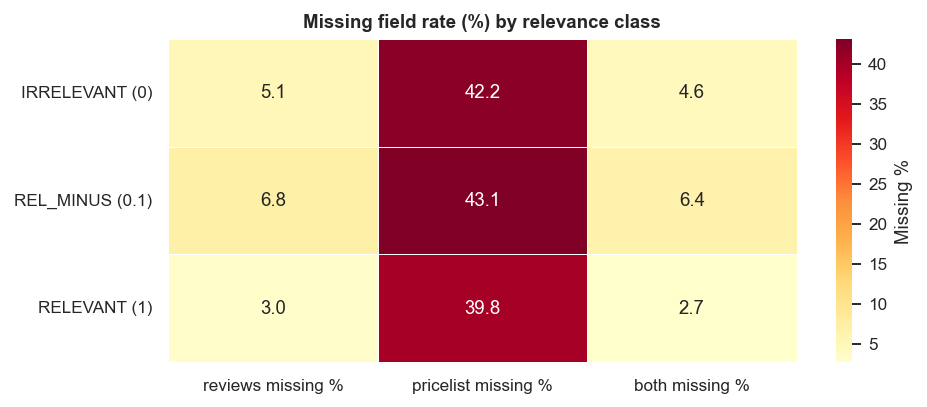

Saved → eda_reports/fig2_missing_by_class.png


In [10]:
# ── 3.1 Missing rate by class — heatmap ───────────────────────────────────
miss_by_class = pd.DataFrame({
    cls: {
        'reviews missing %':  (~df.loc[df[COL_RELEVANCE]==cls, 'has_reviews']).mean() * 100,
        'pricelist missing %': (~df.loc[df[COL_RELEVANCE]==cls, 'has_pricelist']).mean() * 100,
        'both missing %':     (df.loc[df[COL_RELEVANCE]==cls]
                               .pipe(lambda s: (~s['has_reviews'] & ~s['has_pricelist']).mean()) * 100)
    }
    for cls in LABEL_ORDER
}).T
miss_by_class.index = [LABEL_NAMES[c] for c in LABEL_ORDER]

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(miss_by_class, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Missing %'})
ax.set_title('Missing field rate (%) by relevance class', fontweight='bold')
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig2_missing_by_class.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig2_missing_by_class.png')

In [11]:
# ── 3.2 Chi-square test: are missing fields independent of class? ─────────
fields_to_test = [
    ('has_reviews',   'missing reviews'),
    ('has_pricelist', 'missing pricelist'),
]

for col, label in fields_to_test:
    contingency = pd.crosstab(df[COL_RELEVANCE], df[col])
    chi2, p, dof, _ = chi2_contingency(contingency)
    n = contingency.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

    print(f'Chi-square test: class × {col}')
    print(f'  χ²  = {chi2:.2f},  df = {dof},  p = {p:.2e}')
    print(f"  Cramér's V = {cramers_v:.4f}")
    print()
    if cramers_v < 0.1:
        print(f'  V = {cramers_v:.4f} < 0.10 → association strength is VERY WEAK')
        print(f'  → {label} flag alone cannot predict the class.')
    print()

Chi-square test: class × has_reviews
  χ²  = 161.27,  df = 2,  p = 9.54e-36
  Cramér's V = 0.0678

  V = 0.0678 < 0.10 → association strength is VERY WEAK
  → missing reviews flag alone cannot predict the class.

Chi-square test: class × has_pricelist
  χ²  = 26.18,  df = 2,  p = 2.07e-06
  Cramér's V = 0.0273

  V = 0.0273 < 0.10 → association strength is VERY WEAK
  → missing pricelist flag alone cannot predict the class.



However, missing fields define rows that lack evidence for any model making them natural candidates for agent-based search (see §6).

> **§3 Decision — missing fields:**
> Statistical association exists but is negligibly weak (V < 0.1).
> → We do **not** drop rows with missing fields from training.
> → We represent missing fields with a **text placeholder** (`"No reviews."` / `"No price list."`) so the model sees a signal.
> → We flag rows where **both** fields are missing (`has_reviews=False AND has_pricelist=False`) as agent-routing candidates (§6).

## 4. Class 0.1 (RELEVANT_MINUS) — how to handle it

Class 0.1 is a boundary label: assessors could not confidently mark the example
as relevant or irrelevant. We need to understand whether it forms a distinct
semantic cluster or overlaps with the binary classes.

**This section answers Q1** using three complementary approaches:
- descriptive profile (surface statistics)
- Exp A — can a linear model learn 3 classes? (learnability lower bound)
- Exp B — can we even detect 0.1 vs {0,1}? (strongest signal test)
- Exp C — which training strategy for 0.1 maximises binary val accuracy?

**Why TF-IDF + Logistic Regression for experiments A/B/C?**
Embeddings answer "are texts geometrically separable?"
TF-IDF + LR answers "is there a learnable text signal at all?" — it is the
correct lower bound: if a linear bag-of-words model cannot separate 0.1, more
complex models won't either, because the signal does not exist in surface features.

In [12]:
# ── 4.1 Profile of class 0.1 rows ─────────────────────────────────────────
df_01  = df[df[COL_RELEVANCE] == 0.1]
df_bin = df[df[COL_RELEVANCE] != 0.1]

def _class_profile(sdf):
    """Compute profile metrics for a subset of df."""
    return {
        'n':                       len(sdf),
        'reviews missing %':       (~sdf['has_reviews']).mean() * 100,
        'pricelist missing %':     (~sdf['has_pricelist']).mean() * 100,
        'both missing %':          (~sdf['has_reviews'] & ~sdf['has_pricelist']).mean() * 100,
        'review text len (median)': sdf[COL_REVIEWS].str.len().median(),
    }

profile = pd.DataFrame({
    'Class 0 (IRRELEVANT)': _class_profile(df[df[COL_RELEVANCE] == 0.0]),
    'Class 0.1 (REL_MINUS)': _class_profile(df_01),
    'Class 1 (RELEVANT)':   _class_profile(df[df[COL_RELEVANCE] == 1.0]),
}).T.round(1)

print('Class 0.1 profile compared to binary classes:')
display(profile)
profile.to_csv(EDA_REPORTS_DIR / 'table1_class01_profile.csv')
print('Saved → eda_reports/table1_class01_profile.csv')

Class 0.1 profile compared to binary classes:


,n,reviews missing %,pricelist missing %,both missing %,review text len (median)
Class 0 (IRRELEVANT),14504.0000,5.1000,42.2000,4.6000,1677.0000
Class 0.1 (REL_MINUS),4703.0000,6.8000,43.1000,6.4000,1624.0000
Class 1 (RELEVANT),15882.0000,3.0000,39.8000,2.7000,1667.0000


Saved → eda_reports/table1_class01_profile.csv


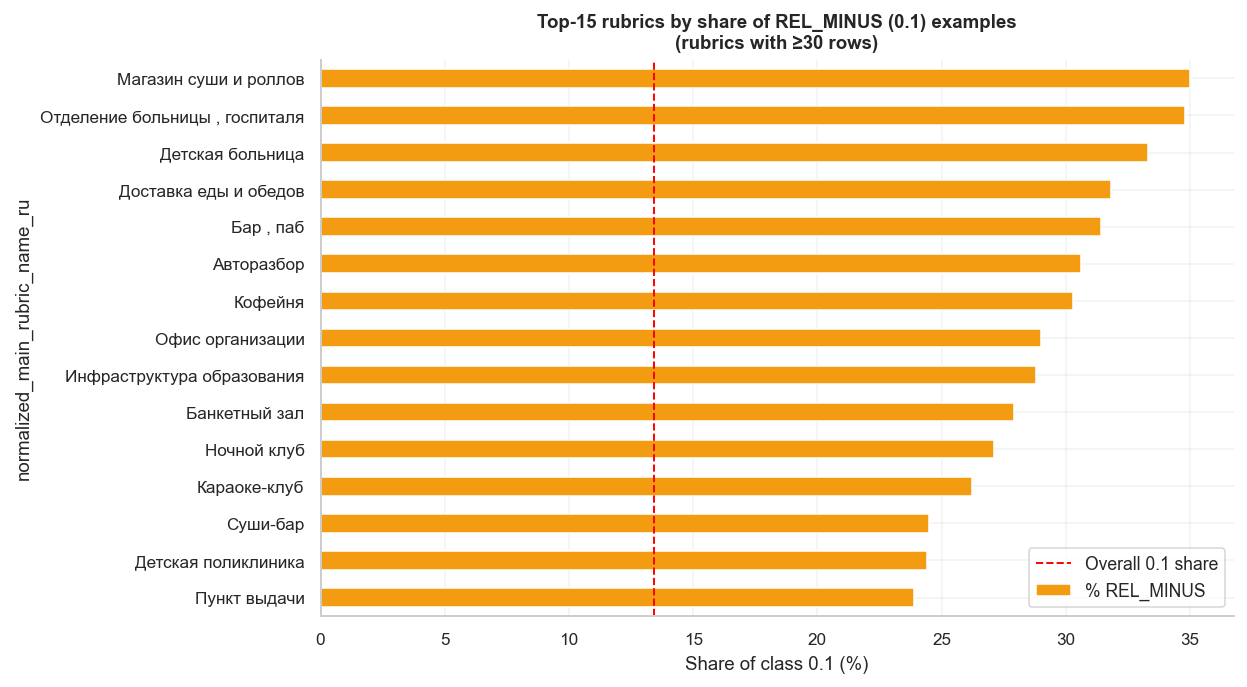

Saved → eda_reports/fig3_rubric_01_share.png


In [13]:
# ── 4.2 Does class 0.1 concentrate in certain rubrics? ────────────────────
rubric_pivot = (
    df.groupby([COL_RUBRIC, COL_RELEVANCE])
      .size()
      .unstack(fill_value=0)
)
rubric_pivot.columns = [LABEL_NAMES[c] for c in rubric_pivot.columns]
rubric_pivot['total'] = rubric_pivot.sum(axis=1)
rubric_pivot['% REL_MINUS'] = (
    rubric_pivot['REL_MINUS (0.1)'] / rubric_pivot['total'] * 100
).round(1)
top_ambiguous = (
    rubric_pivot[rubric_pivot['total'] >= 30]
    .sort_values('% REL_MINUS', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 5))
top_ambiguous['% REL_MINUS'].sort_values().plot(
    kind='barh', ax=ax, color='#F39C12', edgecolor='white'
)
ax.set_title('Top-15 rubrics by share of REL_MINUS (0.1) examples\n(rubrics with ≥30 rows)',
             fontweight='bold')
ax.set_xlabel('Share of class 0.1 (%)')
ax.axvline(len(df_01) / len(df) * 100, color='red',
           linestyle='--', linewidth=1, label='Overall 0.1 share')
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig3_rubric_01_share.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig3_rubric_01_share.png')

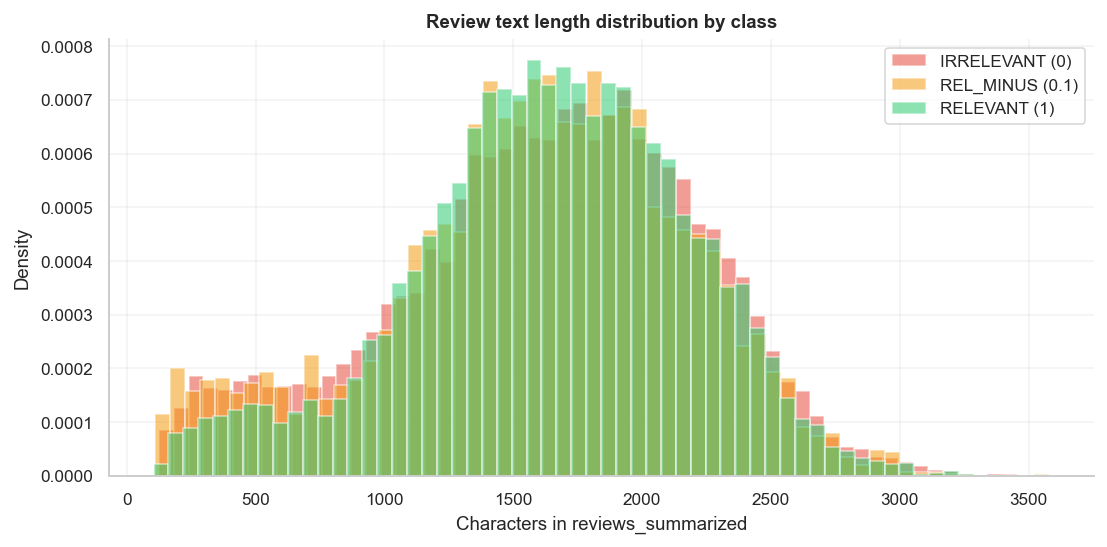

Saved → eda_reports/fig4_review_len_by_class.png


In [14]:
# ── 4.3 Review text length distribution by class ──────────────────────────
df['review_len'] = df[COL_REVIEWS].str.len()   # NaN stays NaN

fig, ax = plt.subplots(figsize=(8, 4))
for cls in LABEL_ORDER:
    vals = df.loc[df[COL_RELEVANCE]==cls, 'review_len'].dropna()
    ax.hist(vals, bins=60, alpha=0.55, label=LABEL_NAMES[cls],
            color=PALETTE[cls], density=True)
ax.set_title('Review text length distribution by class', fontweight='bold')
ax.set_xlabel('Characters in reviews_summarized')
ax.set_ylabel('Density')
ax.legend()
sns.despine()
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig4_review_len_by_class.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig4_review_len_by_class.png')

### Building the combined text feature (used in Exp A / B / C)

Missing `reviews_summarized` / `prices_summarized` are filled with placeholders in the
next cell (after missing-value EDA on `has_reviews` / `has_pricelist`).

All experiments use the same text representation that will be used during
Baseline model training: all text fields concatenated into `combined_text`.
This ensures the diagnostic is consistent with the downstream setup.

In [15]:
# Placeholders for missing summaries (after has_reviews / review_len EDA)
PLACEHOLDER_REVIEWS = 'No reviews.'
PLACEHOLDER_PRICELIST = 'No pricelist.'

n_rev_miss = int(df[COL_REVIEWS].isna().sum())
n_price_miss = int(df[COL_PRICELIST].isna().sum())
df[COL_REVIEWS] = df[COL_REVIEWS].fillna(PLACEHOLDER_REVIEWS)
df[COL_PRICELIST] = df[COL_PRICELIST].fillna(PLACEHOLDER_PRICELIST)
print(
    f'Filled {n_rev_miss:,} missing {COL_REVIEWS}, '
    f'{n_price_miss:,} missing {COL_PRICELIST}'
)


Filled 1,539 missing reviews_summarized, 14,464 missing prices_summarized


In [16]:
def build_combined_text(row: pd.Series) -> str:
    """Combine all text fields into a single string (shared by EDA experiments and Baseline)."""
    reviews = str(row[COL_REVIEWS]).strip()
    pricelist = str(row[COL_PRICELIST]).strip()
    return (
        f"Query: {row[COL_QUERY]}. "
        f"Address:{row[COL_ADDRESS]}."
        f"Name: {row[COL_NAME]}. "
        f"Rubric: {row[COL_RUBRIC]}. "
        f"Reviews: {reviews} "
        f"Pricelist: {pricelist}"
    )

print('Building combined texts...')
df[COL_COMBINED_TEXT] = df.apply(build_combined_text, axis=1)

lens = df[COL_COMBINED_TEXT].str.len()
print(f'Combined text length: median={lens.median():.0f}, '
      f'mean={lens.mean():.0f}, min={lens.min()}, max={lens.max()}')
print('\nExample:')
print(df[COL_COMBINED_TEXT].iloc[0][:300], '...')

Building combined texts...
Combined text length: median=2086, mean=1987, min=140, max=6089

Example:
Query: сигары. Address:Москва, Дубравная улица, 34/29.Name: Tabaccos; Магазин Tabaccos; Табаккос. Rubric: Магазин табака и курительных принадлежностей. Reviews: Организация занимается продажей табака, курительных принадлежностей, вейпов и сопутствующих товаров, а также сувениров и подарков. Отзывы в ...


### Exp A — 3-class TF-IDF + LR (5-fold CV)

**Research question:** Can a linear TF-IDF model learn to classify all three classes, including 0.1?

To answer the question we build the model:

TF-IDF (unigrams + bigrams, top 50k features, sublinear TF scaling, min_df=3) + Logistic Regression (C=1.0, class_weight='balanced', lbfgs solver). Evaluated via 5-fold stratified cross-validation using cross_val_predict. No held-out test set — all 35,089 rows participate in training and evaluation across folds.

In [17]:
X   = df[COL_COMBINED_TEXT].values
y3  = df[COL_RELEVANCE].values           # 0.0, 0.1, 1.0

label_map  = {0.0: 'irrelevant', 0.1: 'relevant_minus', 1.0: 'relevant'}
y3_str     = np.array([label_map[v] for v in y3])

pipe_3class = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=3)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced',
                                 random_state=RANDOM_STATE, solver='lbfgs'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('Running 5-fold CV for 3-class model (~1-2 min)...')
y3_pred = cross_val_predict(pipe_3class, X, y3_str, cv=cv, n_jobs=-1)

print('\n=== Exp A: 3-class TF-IDF + LR (5-fold CV) ===')
print(classification_report(y3_str, y3_pred, digits=3))

Running 5-fold CV for 3-class model (~1-2 min)...

=== Exp A: 3-class TF-IDF + LR (5-fold CV) ===
                precision    recall  f1-score   support

    irrelevant      0.555     0.541     0.548     14504
      relevant      0.599     0.533     0.564     15882
relevant_minus      0.238     0.345     0.281      4703

      accuracy                          0.511     35089
     macro avg      0.464     0.473     0.464     35089
  weighted avg      0.532     0.511     0.520     35089



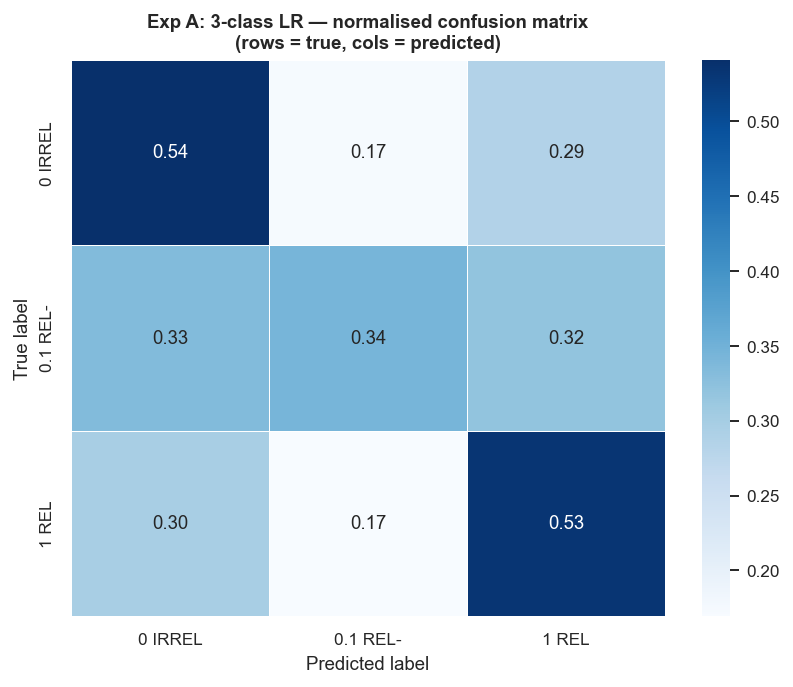

Saved → eda_reports/fig5_cm_3class.png

Class 0.1 predictions breakdown (true = relevant_minus):
  predicted as irrelevant: 33.5%
  predicted as relevant_minus: 34.5%
  predicted as relevant: 32.0%


In [18]:
# ── Exp A confusion matrix ─────────────────────────────────────────────────
LABELS_3 = ['irrelevant', 'relevant_minus', 'relevant']
cm3 = confusion_matrix(y3_str, y3_pred, labels=LABELS_3, normalize='true')

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['0 IRREL', '0.1 REL-', '1 REL'],
            yticklabels=['0 IRREL', '0.1 REL-', '1 REL'],
            ax=ax, linewidths=0.5)
ax.set_title('Exp A: 3-class LR — normalised confusion matrix\n(rows = true, cols = predicted)',
             fontweight='bold')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig5_cm_3class.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig5_cm_3class.png')

# How much of 0.1 leaks into each class?
idx01 = LABELS_3.index('relevant_minus')
row01 = cm3[idx01]
print('\nClass 0.1 predictions breakdown (true = relevant_minus):')
for cls, share in zip(LABELS_3, row01):
    print(f'  predicted as {cls}: {share:.1%}')

Exp A (3-class TF-IDF + LR, 5-fold CV) yields F1 = 0.282 for relevant_minus. While this is above the random baseline (~0.236), the confusion breakdown reveals that predictions are nearly uniformly distributed: 34.6% correctly predicted as 0.1, but 33.5% misclassified as irrelevant and 31.9% as relevant. A class with genuine semantic boundaries would show a dominant correct-prediction bin and concentrated errors toward one neighbour — not a near-uniform split across all three. Precision of 0.238 means that 76% of all rows the model labelled as relevant_minus were wrong. So the class is not learnable. 

### Exp B — detect class 0.1 vs {0, 1}

**Research question:** Is there ANY learnable text pattern that separates 0.1 from the rest?

To answer the question we build the binary classifier: TF-IDF (unigrams + bigrams, top 50k features, sublinear TF scaling, min_df=3) + Logistic Regression (C=1.0, class_weight='balanced'). Target variable: IS-0.1 (1) vs NOT-0.1 (0). Evaluated via 5-fold stratified cross-validation on the full dataset (35,089 rows).

This is the strictest possible test. If a binary IS-0.1 detector cannot beat the
random baseline, there is no surface-level signal — class 0.1 is assessor noise or uncertainty, not a real semantic category.

Random baseline F1 for a class with prevalence p: `2p / (1 + p)`

In [19]:
y_detect = (df[COL_RELEVANCE] == 0.1).astype(int).values

pipe_detect = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=3)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced',
                                 random_state=RANDOM_STATE, solver='lbfgs'))
])

print('Running 5-fold CV for 0.1 detection task...')
y_detect_pred = cross_val_predict(
    pipe_detect, df[COL_COMBINED_TEXT].values, y_detect, cv=cv, n_jobs=-1
)

print('\n=== Exp В: detect class 0.1 vs {0,1} (5-fold CV) ===')
print(classification_report(y_detect, y_detect_pred,
                             target_names=['NOT 0.1 (0 or 1)', 'IS 0.1'], digits=3))

p01 = (df[COL_RELEVANCE] == 0.1).mean()
random_f1 = 2 * p01 / (1 + p01)
print(f'Random-baseline F1 for IS-0.1 (prevalence={p01:.3f}): ~{random_f1:.3f}')

Running 5-fold CV for 0.1 detection task...

=== Exp В: detect class 0.1 vs {0,1} (5-fold CV) ===
                  precision    recall  f1-score   support

NOT 0.1 (0 or 1)      0.895     0.794     0.841     30386
          IS 0.1      0.229     0.396     0.290      4703

        accuracy                          0.740     35089
       macro avg      0.562     0.595     0.566     35089
    weighted avg      0.805     0.740     0.767     35089

Random-baseline F1 for IS-0.1 (prevalence=0.134): ~0.236


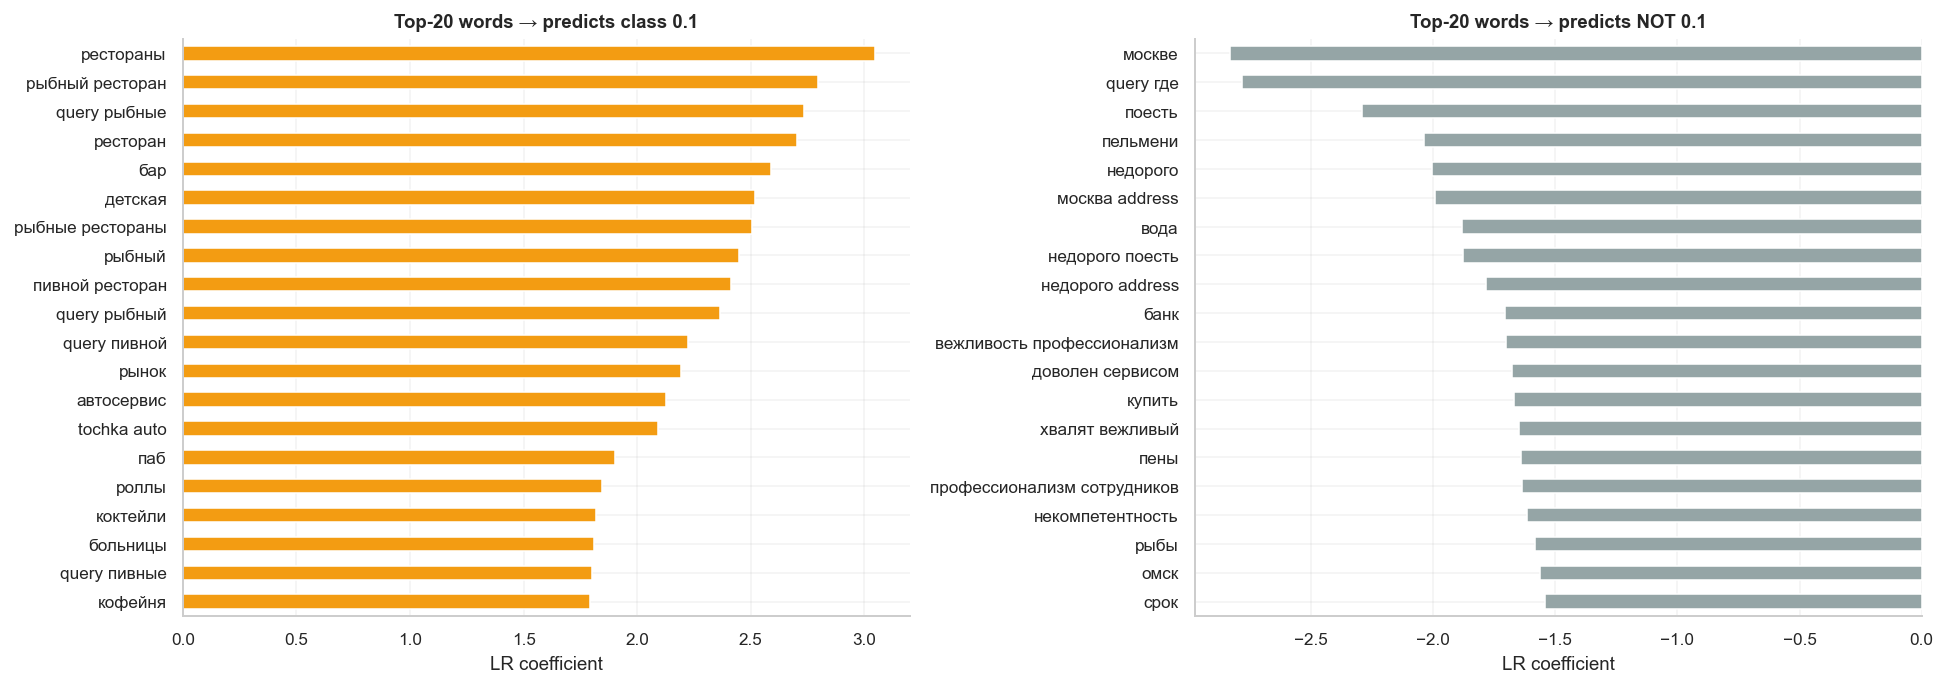

Saved → eda_reports/fig6_expB_coefs.png

Interpretation: if top words are generic rather than semantically specific,
the model is overfitting to surface noise — confirming 0.1 is not a real category.


In [20]:
# ── Top words driving the 0.1 prediction ─────────────────────────────────
pipe_detect.fit(df[COL_COMBINED_TEXT].values, y_detect)
vocab   = pipe_detect.named_steps['tfidf'].get_feature_names_out()
coefs   = pipe_detect.named_steps['clf'].coef_[0]
top_pos = pd.Series(coefs, index=vocab).nlargest(20)
top_neg = pd.Series(coefs, index=vocab).nsmallest(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_pos.sort_values().plot(kind='barh', ax=axes[0], color='#F39C12')
axes[0].set_title('Top-20 words → predicts class 0.1', fontweight='bold')
axes[0].set_xlabel('LR coefficient')

top_neg.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='#95A5A6')
axes[1].set_title('Top-20 words → predicts NOT 0.1', fontweight='bold')
axes[1].set_xlabel('LR coefficient')

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig6_expB_coefs.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig6_expB_coefs.png')
print()
print('Interpretation: if top words are generic rather than semantically specific,')
print('the model is overfitting to surface noise — confirming 0.1 is not a real category.')

The random baseline F1 in Exp A for IS-0.1 at prevalence 13.4% is 0.236. The model achieves F1 = 0.289 — a margin of 0.053 above random. At first glance this suggests some signal exists, but the picture becomes clearer when looking at precision and recall separately.

Recall = 0.396 means the model finds only 40% of class 0.1 rows — it misses 60%. Precision = 0.227 means that three quarters of everything the model labelled IS-0.1 were wrong. Due to class_weight='balanced', the model is forced to predict 0.1 aggressively in order to catch anything at all, generating a large number of false positives on rows from classes 0 and 1.

The gap over the random baseline (0.053) at this level of precision does not indicate that the model found a real pattern — rather, it picked up weak surface correlations, such as certain rubrics or text lengths being slightly more associated with the 0.1 label. This is not a semantic signal; it is a statistical artefact of the annotation process.

Exp B provides independent confirmation of the same conclusion: even when the model's full capacity is directed exclusively at detecting 0.1, the result barely exceeds the random baseline and is practically unusable (precision 0.229). Two independent experiments converge on the same finding — there is no stable text signal that separates class 0.1 from the rest.

### Exp C — which training strategy for class 0.1 maximises binary val accuracy?

Three strategies for including 0.1 rows in the training set:
- **B1:** assign label 0 ("when uncertain, call it irrelevant")
- **B2:** assign label 1 ("when uncertain, call it relevant")
- **B3:** exclude 0.1 rows from training entirely

Evaluated by accuracy on a held-out **binary** val set (no 0.1 rows).
The winning strategy is used in §7 when preparing Baseline artefacts.

Having established in Exp A and Exp B that class 0.1 carries no learnable signal of its own, the practical question becomes: what is the best way to handle these 4,703 rows when training the binary classifier? Exp C compares three strategies by training the same TF-IDF + LR pipeline under each and measuring accuracy on a held-out binary val set (20% of binary rows, no 0.1 rows). The val set contains only classes 0 and 1, so the metric is a clean measure of how well the model learned the true binary boundary — uncontaminated by ambiguous labels.

In [21]:
df_binary_exp = df[df[COL_RELEVANCE] != 0.1].copy()
df_01_exp    = df[df[COL_RELEVANCE] == 0.1].copy()

X_bin = df_binary_exp[COL_COMBINED_TEXT].values
y_bin = df_binary_exp[COL_RELEVANCE].values

X_tr_bin, X_val_exp, y_tr_bin, y_val_exp = train_test_split(
    X_bin, y_bin, test_size=0.20, stratify=y_bin, random_state=RANDOM_STATE
)

pipe_binary = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=3)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced',
                                 random_state=RANDOM_STATE, solver='lbfgs'))
])

X_01 = df_01_exp[COL_COMBINED_TEXT].values
results_b = {}

# B3: exclude 0.1
pipe_binary.fit(X_tr_bin, y_tr_bin)
results_b['B3: exclude 0.1'] = accuracy_score(y_val_exp, pipe_binary.predict(X_val_exp))

# B1: 0.1 → label 0
pipe_binary.fit(np.concatenate([X_tr_bin, X_01]),
                np.concatenate([y_tr_bin, np.zeros(len(X_01))]))
results_b['B1: 0.1 → class 0'] = accuracy_score(y_val_exp, pipe_binary.predict(X_val_exp))

# B2: 0.1 → label 1
pipe_binary.fit(np.concatenate([X_tr_bin, X_01]),
                np.concatenate([y_tr_bin, np.ones(len(X_01))]))
results_b['B2: 0.1 → class 1'] = accuracy_score(y_val_exp, pipe_binary.predict(X_val_exp))

print('=== Exp C: binary val accuracy by class-0.1 training strategy ===')
best_acc = max(results_b.values())
for name, acc in sorted(results_b.items(), key=lambda x: -x[1]):
    marker = ' ← BEST' if acc == best_acc else ''
    print(f'  {name}: {acc:.4f}{marker}')

=== Exp C: binary val accuracy by class-0.1 training strategy ===
  B3: exclude 0.1: 0.6366 ← BEST
  B1: 0.1 → class 0: 0.6318
  B2: 0.1 → class 1: 0.6293


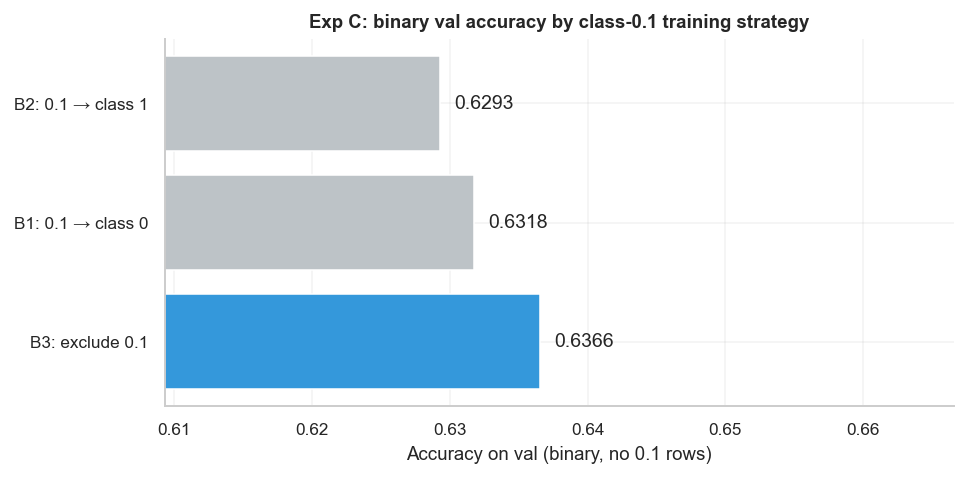

Saved → eda_reports/fig7_expC_strategy.png


In [22]:
fig, ax = plt.subplots(figsize=(7, 3.5))
names  = list(results_b.keys())
vals   = [results_b[n] for n in names]
colors = ['#3498DB' if v == max(vals) else '#BDC3C7' for v in vals]
bars   = ax.barh(names, vals, color=colors, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=10)
ax.set_xlim(min(vals) - 0.02, max(vals) + 0.03)
ax.set_title('Exp C: binary val accuracy by class-0.1 training strategy', fontweight='bold')
ax.set_xlabel('Accuracy on val (binary, no 0.1 rows)')
sns.despine()
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig7_expC_strategy.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig7_expC_strategy.png')

> **§4 Decision — class 0.1:**
>
> | Experiment | Key number | Conclusion |
> |---|---|---|
> | Exp A (3-class F1 for 0.1) | F1 = 0.282; confusion breakdown: 33.7% → irrelevant, 34.6% → relevant_minus, 31.6% → relevant | Near-uniform misclassification across all three bins — no stable decision boundary for class 0.1 |
> | Exp B (IS-0.1 detection F1) | F1 = 0.290, random baseline = 0.236, precision = 0.229 | Margin of 0.054 over random reflects weak surface correlations, not semantic signal; precision makes detector practically unusable |
> | Exp C (binary val accuracy) | B3: Acc = 0.6392, B1: Acc = 0.6329, B2: Acc = 0.6305; max spread = 0.0087 | B3 (exclude 0.1) yields the best binary val accuracy — including boundary examples in any form marginally degrades the learned decision boundary |
> | Descriptive profile | reviews missing: class 0.1 → 7%, class 1 → 3% | Higher missing rate consistent with assessor uncertainty rather than a distinct relevance level |
>
> Three independent experiments converge on the same conclusion. Exp A shows that a 3-class linear model cannot find a stable boundary for class 0.1: predictions are distributed near-uniformly across all three classes, indicating the model has learned nothing specific about this label. Exp B confirms this from a different angle: even a dedicated binary detector trained solely to identify 0.1 rows barely exceeds the random baseline, with precision low enough to make it operationally useless. Exp C translates the finding into a practical training decision: excluding class 0.1 from training entirely (B3) produces the highest binary val accuracy, consistent with asymmetric label noise theory (Natarajan et al., 2013) — at noise rate ρ ≈ 0.31, including mislabelled boundary examples adds noise that marginally degrades the learned boundary. The descriptive profile supports the assessor-noise hypothesis throughout: class 0.1 marks annotation uncertainty driven by thin evidence, not a semantically distinct relevance level.
>
> **Decision: train on 2 classes (0 and 1); exclude class 0.1 from all splits.**
> - Remove class 0.1 from `train`, `val`, and `eval` (strategy B3, Exp C).
> - Class 0.1 rows are retained separately in `df_01_only` for post-hoc error analysis and potential Confident Learning (Northcutt et al., 2021) after Baseline training.
> - Primary metric: **Accuracy on {0, 1}**; secondary: **macro-F1** as an imbalance guard.

https://link.springer.com/article/10.1007/s10994-020-05915-2

chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://arxiv.org/pdf/2007.08199

## 5. Train / Val / Eval split

> **§5 Decision — data split:**
>
> **Split:** 70 / 15 / 15 row-level stratified split on binary rows {0, 1} only. Class 0.1 rows are excluded from all splits (strategy B3, Exp C) and retained separately in `df_01_only` for post-hoc analysis. Val and eval contain only original labels 0 and 1 — verified by assertion. Train contains 70% of binary rows with natural class distribution (~48/52), reflecting the real data without any label manipulation.
>
> **Why no query-level split?** The same query appears with multiple organisations (different rows). A query-level split would be stricter and closer to production, but leaves some queries with very few labelled organisations in val/eval. Given project constraints we use row-level stratified split and document this assumption.
>
> **Class balance:** Train class ratio is ~48/52 (0 vs 1), reflecting the natural distribution. No soft negatives are introduced, so no artificial imbalance is created. `class_weight='balanced'` in LR handles the minor natural imbalance implicitly. For transformer fine-tuning at later stages this remains a non-issue given the near-equal split.
>
> **Provenance tracking:** `was_soft_negative` is set to `False` for all rows in all three splits — no soft negatives are present. The flag is retained in the schema for consistency with the project's artefact contract and to support potential future experiments where B1 strategy is revisited at the transformer fine-tuning stage. Class 0.1 rows stored in `df_01_only` enable: (1) post-hoc error analysis — running the trained Baseline on these rows to see how they are classified; (2) application of Confident Learning (Northcutt et al., 2021) via `cleanlab` on out-of-fold probabilities to identify which 0.1 examples the model confidently assigns to 0 or 1, providing empirical grounds for label revision; (3) re-evaluation of strategy B1 with instance weighting (Goldberger & Ben-Reuven, 2017) at the transformer fine-tuning stage, where higher model capacity may interact differently with boundary examples than TF-IDF + LR.
>
> **Primary metric:** Accuracy on {0, 1}; secondary: macro-F1 as an imbalance guard.

This section produces the files consumed directly by the Baseline training pipeline.
No further preprocessing is needed after this step.

**What happens here:**
1. Add target as integer binary labels.
2. Display class balance in the baseline splits
3. Conduct sanity checks on the baseline splits
4. Make a dataset statistics table for all the splits
5. Save `train_baseline.parquet`, `val_baseline.parquet`, `eval_baseline.parquet`, `rel_minus_baseline.parquet`.

Во-первых, числовые метки исключают опечатки. 'irrelevant' и 'irrelavant' — разные строки, которые молча создадут третий класс.

Во-вторых, большинство функций потерь (BCELoss, CrossEntropyLoss) ожидают числа. При строковых метках нужен дополнительный LabelEncoder на каждом этапе пайплайна.

В-третьих, бинарная метка 0/1 позволяет напрямую интерпретировать predict_proba[:, 1] как вероятность релевантности — это удобно для порога confidence в Stage 3 проекта.

### Split

In [23]:
VAL_RATIO  = 0.15
EVAL_RATIO = 0.15

# ── Step 1: разделяем бинарные строки и класс 0.1 
df_binary  = df[df[COL_RELEVANCE] != 0.1].copy()
df_01_only = df[df[COL_RELEVANCE] == 0.1].copy()

# ── Step 2: отрезаем eval 
df_trainval, df_eval = train_test_split(
    df_binary, test_size=EVAL_RATIO,
    stratify=df_binary[COL_RELEVANCE], random_state=RANDOM_STATE
)

# ── Step 3: отрезаем val ───────────────────────────────────────────────────
val_relative = VAL_RATIO / (1 - EVAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval, test_size=val_relative,
    stratify=df_trainval[COL_RELEVANCE], random_state=RANDOM_STATE
)

# ── Step 4: добавляем целевую колонку  ──────────────────
# combined_text уже есть в df с раздела 4 — не пересчитываем
for sdf in [df_train, df_val, df_eval, df_01_only]:
    sdf[TARGET]          = sdf[COL_RELEVANCE].map(LABEL_MAP_BINARY)

# ── Sanity checks ──────────────────────────────────────────────────────────
assert (df_train[COL_RELEVANCE] == 0.1).sum() == 0, "0.1 rows found in train!"
assert (df_val[COL_RELEVANCE]   == 0.1).sum() == 0, "0.1 rows found in val!"
assert (df_eval[COL_RELEVANCE]  == 0.1).sum() == 0, "0.1 rows found in eval!"
assert (df_01_only[COL_RELEVANCE] == 0.1).all(),     "Non-0.1 rows found in ood!"
assert set(df_train[TARGET].unique()) == {0, 1},     "Unexpected label values in train!"
print("Sanity checks passed.")
print(f'\nClass 0.1 rows retained separately: {len(df_01_only):,}\n')
print('Shape of train:', df_train.shape)
print('Shape of val:', df_val.shape)
print('Shape of eval:', df_eval.shape)
print('Shape of 01 only:', df_01_only.shape)

# Combined_text examples
print()
print(f'=== Train sample ({TARGET}=0) ===')
print(df_train[df_train[TARGET] == 0].iloc[0][COL_COMBINED_TEXT][:250])
print()
print(f'=== Train sample ({TARGET}=1) ===')
print(df_train[df_train[TARGET] == 1].iloc[0][COL_COMBINED_TEXT][:250])
print()
print('=== OOD sample (class 0.1, excluded from training) ===')
print(df_01_only.iloc[0][COL_COMBINED_TEXT][:250])

Sanity checks passed.

Class 0.1 rows retained separately: 4,703

Shape of train: (21270, 13)
Shape of val: (4558, 13)
Shape of eval: (4558, 13)
Shape of 01 only: (4703, 13)

=== Train sample (label=0) ===
Query: рено. Address:Санкт-Петербург, Складская улица, 6.Name: Автофранция; Avtofrantsiya; Автоф; Автоклиника; СТО Автофранция. Rubric: Автосервис , автотехцентр. Reviews: Организация занимается обслуживанием и ремонтом автомобилей, специализируясь н

=== Train sample (label=1) ===
Query: лучшие итальянские рестораны в москве. Address:Москва, Мичуринский проспект, 3.Name: Osteria Mario. Rubric: Ресторан. Reviews: Организация занимается предоставлением ресторанных услуг, включая завтраки и обеды. Тональность отзывов преимуществе

=== OOD sample (class 0.1, excluded from training) ===
Query: спортзал где 1 занятие бесплатно. Address:Москва, Страстной бульвар, 13А.Name: Унца Унца Спорт; Unza Unza Sport. Rubric: Фитнес-клуб. Reviews: Организация «Унца Унца Спорт» предоставляет услуги фит

### Split overview table

In [24]:
splits_info = [
    ('Train',                  df_train),
    ('Val',                    df_val),
    ('Eval',                   df_eval)
]

overview = pd.DataFrame([
    {
        'Split':    name,
        'Total':    len(sdf),
        'Label 0':  int((sdf[TARGET] == 0).sum()),
        'Label 1':  int((sdf[TARGET] == 1).sum()),
        'Label 0 %': round((sdf[TARGET] == 0).mean() * 100, 1),
        'Label 1 %': round((sdf[TARGET] == 1).mean() * 100, 1),
    }
    for name, sdf in splits_info
]).set_index('Split')


display(
    overview.style
    .format('{:,}', subset=['Total', 'Label 0', 'Label 1'])
    .format('{:.1f}%', subset=['Label 0 %', 'Label 1 %'])
    .set_properties(**{'text-align': 'right'})
    .set_table_styles([
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'right')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f5f5f5')]},
    ])
)

,Total,Label 0,Label 1,Label 0 %,Label 1 %
Split,,,,,
Train,"21,270","10,152","11,118",47.7%,52.3%
Val,"4,558","2,176","2,382",47.7%,52.3%
Eval,"4,558","2,176","2,382",47.7%,52.3%


### Class distribution

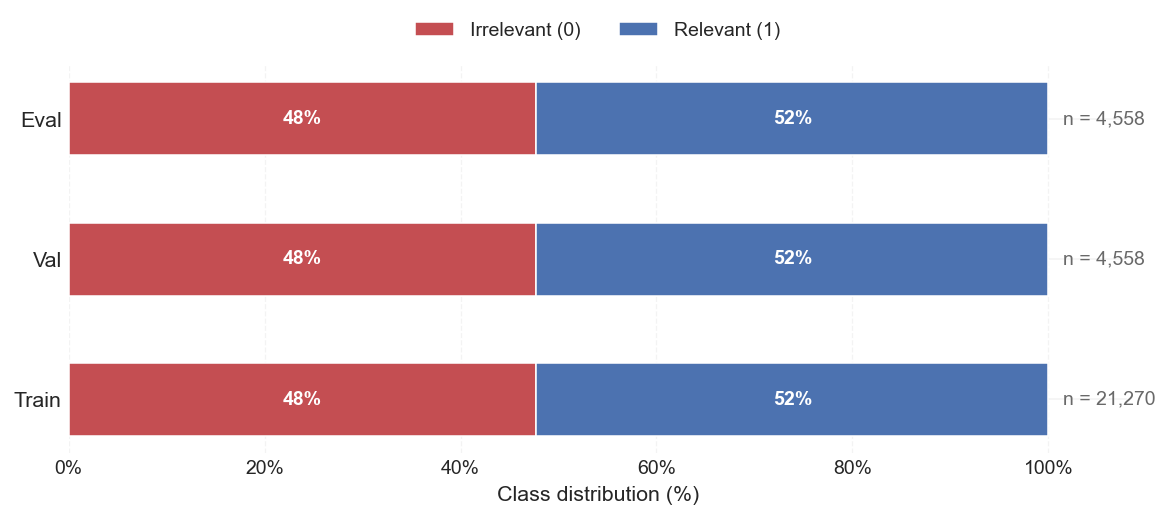

Saved → eda_reports/fig11_split_class_balance.png


In [25]:
plot_df = overview.reset_index()

splits = plot_df['Split'].values
label0 = plot_df['Label 0'].values
label1 = plot_df['Label 1'].values
totals = plot_df['Total'].values

label0_pct = label0 / totals * 100
label1_pct = label1 / totals * 100

# Figure
fig, ax = plt.subplots(figsize=(8.5, 3.8))

# Muted paper-friendly colors
c0 = '#C44E52'
c1 = '#4C72B0'

# Bars
ax.barh(
    splits,
    label0_pct,
    height=0.52,
    color=c0
)

ax.barh(
    splits,
    label1_pct,
    left=label0_pct,
    height=0.52,
    color=c1
)

# Internal labels
for i in range(len(splits)):

    # Label 0
    if label0_pct[i] > 8:
        ax.text(
            label0_pct[i] / 2,
            i,
            f'{label0_pct[i]:.0f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

    # Label 1
    if label1_pct[i] > 8:
        ax.text(
            label0_pct[i] + label1_pct[i] / 2,
            i,
            f'{label1_pct[i]:.0f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold'
        )

    # Total count on the right
    ax.text(
        101.5,
        i,
        f'n = {totals[i]:,}',
        va='center',
        fontsize=10,
        color='dimgray'
    )

# Styling 
ax.set_xlim(0, 108)

ax.set_xlabel('Class distribution (%)', fontsize=11)
ax.set_ylabel('')

# Clean axes
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

# Ticks
ax.tick_params(axis='y', length=0, labelsize=11)
ax.tick_params(axis='x', length=0, labelsize=10)

# Light grid
ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.7,
    alpha=0.22
)

# Percent ticks
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels([f'{x}%' for x in range(0, 101, 20)])

# Minimal legend
legend = ax.legend(
    ['Irrelevant (0)', 'Relevant (1)'],
    frameon=False,
    loc='lower center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=10
)

plt.tight_layout()
plt.show()

fig.savefig(EDA_REPORTS_DIR / 'fig11_split_class_balance.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig11_split_class_balance.png')

### Dataset statistics table

In [26]:
def vocab_size(texts):
    tokens = set()
    for t in texts:
        tokens.update(t.lower().split())
    return len(tokens)


def token_stats(texts):
    lengths = [len(t.split()) for t in texts]
    return {
        'total_tokens': sum(lengths)
    }


# Build statistics 
splits = [
    ('Train', df_train),
    ('Val',   df_val),
    ('Eval',  df_eval)
]

rows = []

for name, sdf in splits:

    texts = sdf[COL_COMBINED_TEXT].tolist()

    tstat = token_stats(texts)

    n0 = int((sdf[TARGET] == 0).sum())
    n1 = int((sdf[TARGET] == 1).sum())

    rows.append({
        'Split':            name,
        'Documents':        len(sdf),
        'Irrelevant (0)':   n0,
        'Relevant (1)':     n1,
        'Vocabulary Size':  vocab_size(texts),
        'Total Tokens':     tstat['total_tokens']
    })


stats_df = (
    pd.DataFrame(rows)
    .set_index('Split')
    .T
)

stats_df = stats_df.apply(pd.to_numeric)

# styling

caption = (
    'Table 3. Dataset statistics across data splits.'
)

styled_stats = (
    stats_df.style

    # Number formatting
    .format('{:,.0f}')

    # Typography
    .set_properties(**{
        'font-size':        '11pt',
        'text-align':       'right',
        'padding':          '6px 10px',
        'border':           'none',
        'font-family':      'Arial'
    })

    # Header styling
    .set_table_styles([

        # Column headers
        {
            'selector': 'th.col_heading',
            'props': [
                ('font-weight', 'bold'),
                ('font-size', '11pt'),
                ('text-align', 'center'),
                ('border-bottom', '1.5px solid black'),
                ('padding', '8px 10px'),
                ('background-color', 'white')
            ]
        },

        # Row labels
        {
            'selector': 'th.row_heading',
            'props': [
                ('font-weight', 'normal'),
                ('text-align', 'left'),
                ('padding', '6px 10px'),
                ('background-color', 'white')
            ]
        },

        # Entire table
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('margin', '0 auto'),
                ('border-top', '2px solid black'),
                ('border-bottom', '2px solid black')
            ]
        },

        # Zebra rows
        {
            'selector': 'tbody tr:nth-child(even)',
            'props': [
                ('background-color', '#fafafa')
            ]
        },

        # Caption
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'bottom'),
                ('font-size', '10pt'),
                ('font-style', 'italic'),
                ('padding-top', '10px')
            ]
        }
    ])

    .set_caption(caption)
)

print('=== Dataset statistics ===')

display(styled_stats)

# ── Save CSV ───────────────────────────────────────────────────────────────
stats_df.to_csv(
    EDA_REPORTS_DIR / 'table2_dataset_stats.csv'
)

print('\n Saved → eda_reports/table2_dataset_stats.csv')

=== Dataset statistics ===


Split,Train,Val,Eval
Documents,"21,270","4,558","4,558"
Irrelevant (0),"10,152","2,176","2,176"
Relevant (1),"11,118","2,382","2,382"
Vocabulary Size,"192,706","80,829","80,718"
Total Tokens,"6,003,232","1,282,737","1,281,283"



 Saved → eda_reports/table2_dataset_stats.csv


In [27]:
from sklearn.feature_extraction.text import CountVectorizer

X_train = df_train[COL_COMBINED_TEXT].values
vec = CountVectorizer(max_features=50, ngram_range=(1,1))
vec.fit(X_train)

freqs = zip(vec.get_feature_names_out(),
            vec.transform(X_train).sum(axis=0).A1)

for word, cnt in sorted(freqs, key=lambda x: -x[1])[:100]:
    print(f'{word:25s} {cnt:}')

хвалят                    82762
критикуют                 61690
на                        55316
отмечают                  50287
отзыв                     45309
положительный             42830
цены                      40619
за                        37524
качество                  34309
обслуживание              30647
pricelist                 29923
пользователь              29620
для                       25167
но                        24862
подчёркивают              22665
reviews                   22127
по                        22079
name                      21277
address                   21271
query                     21270
rubric                    21270
профессионализм           20977
персонал                  20381
организация               19835
10                        19434
11                        18745
12                        18662
13                        18443
положительные             18387
персонала                 18279
14                        18170
15      

In [28]:
df_train[COL_COMBINED_TEXT].loc[0]

'Query: сигары. Address:Москва, Дубравная улица, 34/29.Name: Tabaccos; Магазин Tabaccos; Табаккос. Rubric: Магазин табака и курительных принадлежностей. Reviews: Организация занимается продажей табака, курительных принадлежностей, вейпов и сопутствующих товаров, а также сувениров и подарков. Отзывы в основном положительные, хвалят ассортимент и обслуживание, но есть замечания по поводу работы персонала и условий оплаты. | 1. Жалуются на отсутствие сигарет | 2. Хвалят большой ассортимент | 3. Отмечают вежливый персонал и наличие табака для кальяна | 4. Критикуют качество товаров и отношение персонала | 5. Подчёркивают наличие всего необходимого и быстрое обслуживание | 6. Жалуются на проблемы с оплатой картой | 7. Хвалят выбор стиков и продавца Марину | 8. Критикуют несоблюдение графика работы | 9. Рекомендуют магазин за хороший выбор и помощь продавца | 10. Отмечают вежливость персонала | 11. Подчёркивают удобство расположения и широкий ассортимент | 12. Жалуются на неуважительное отно

### Save data

In [29]:
# Save artefacts
for name, sdf in [('train', df_train), ('val', df_val),
                  ('eval', df_eval),   ('rel_minus', df_01_only)]:
    out  = sdf[[c for c in KEEP_COLS if c in sdf.columns]]
    path = Path(PROCESSED_DATA_DIR) / f'{name}_baseline.parquet'
    out.to_parquet(path, index=False)
    print(f'Saved {name}_baseline ({len(out):,} rows) → {path}')

print()
print('eval_baseline.parquet is LOCKED — do not open until final evaluation.')
print()
print('Column schema:')
print(pd.read_parquet(
    Path(PROCESSED_DATA_DIR) / 'train_baseline.parquet'
).dtypes.to_string())

Saved train_baseline (21,270 rows) → D:\My_courses\NLP_ODS_2026\yandex_relevance\data\processed\train_baseline.parquet
Saved val_baseline (4,558 rows) → D:\My_courses\NLP_ODS_2026\yandex_relevance\data\processed\val_baseline.parquet
Saved eval_baseline (4,558 rows) → D:\My_courses\NLP_ODS_2026\yandex_relevance\data\processed\eval_baseline.parquet
Saved rel_minus_baseline (4,703 rows) → D:\My_courses\NLP_ODS_2026\yandex_relevance\data\processed\rel_minus_baseline.parquet

eval_baseline.parquet is LOCKED — do not open until final evaluation.

Column schema:
permalink                           int64
text                               object
name                               object
address                            object
normalized_main_rubric_name_ru     object
label                               int64
relevance                         float64
reviews_summarized                 object
prices_summarized                  object


> **§5 Decision — data split:**
> | File | Rows | Used for |
> |---|---|---|
> | `train.parquet` | 70% binary (0.1 excluded) | Baseline model training |
> | `val.parquet` | 15% binary only | Model selection & hyperparameter tuning |
> | `eval.parquet` | 15% binary only | **Final evaluation only — locked** |
> | `rel_minus.parquet` | 0.1 labelled only | 
>
> Key columns: `combined_text` (model input with query), `label` ∈ {0, 1} (target)

## 6. Agent routing candidates: rows lacking sufficient evidence

The LLM agent (with Tavily web search) is expensive. We want to route to it
only the examples where internal evidence (reviews, pricelist) is insufficient
for the baseline model.

This section characterises those rows **and empirically validates the routing rule**
by measuring how much the baseline model's accuracy drops on rows with missing fields.

In [30]:
# ── 6.1 Define routing categories ─────────────────────────────────────────
def routing_category(row):
    r, p = row['has_reviews'], row['has_pricelist']
    if not r and not p: return 'A: both missing'
    if not r and p:     return 'B: no reviews'
    if r and not p:     return 'C: no pricelist'
    return 'D: full'

df['routing'] = df.apply(routing_category, axis=1)

cat_counts = df['routing'].value_counts().sort_index()
print('Routing category distribution (full dataset):')
for cat, n in cat_counts.items():
    print(f'  {cat}: {n:,} ({n/len(df)*100:.1f}%)')

Routing category distribution (full dataset):
  A: both missing: 1,398 (4.0%)
  B: no reviews: 141 (0.4%)
  C: no pricelist: 13,066 (37.2%)
  D: full: 20,484 (58.4%)


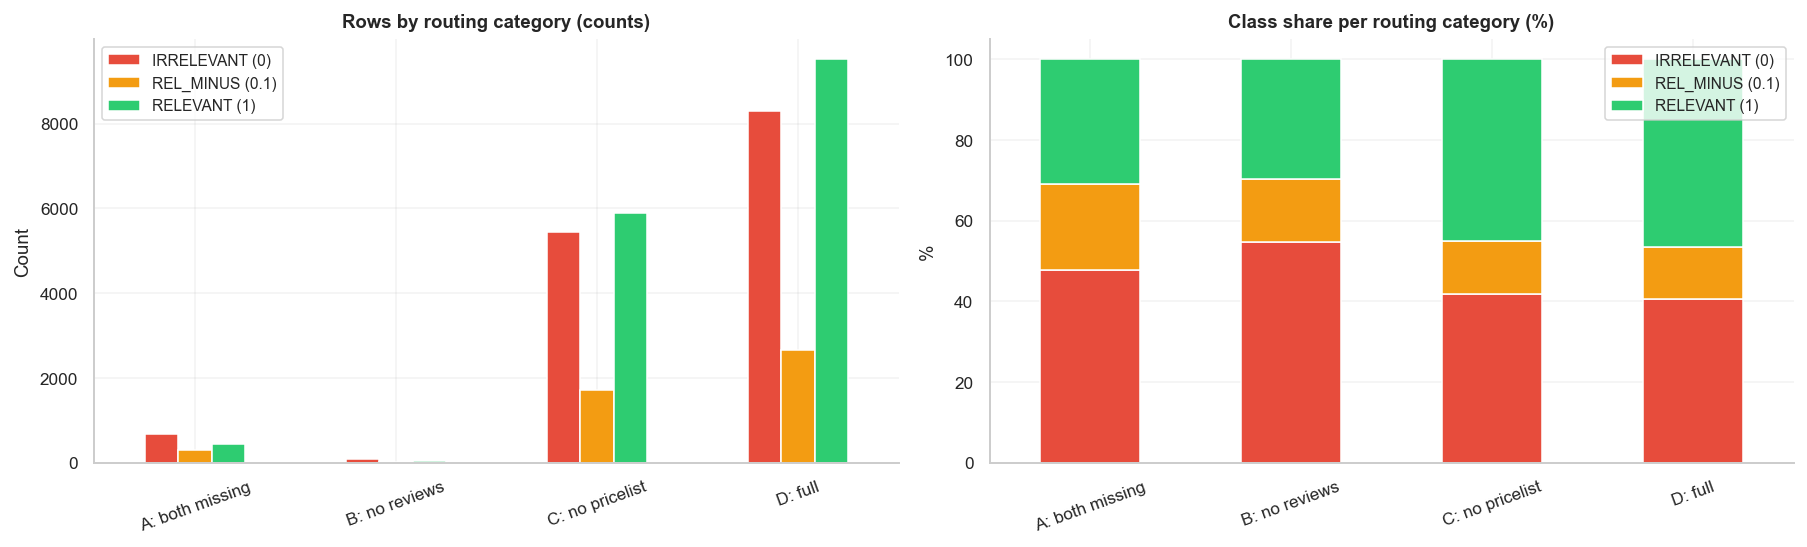

Saved → eda_reports/fig9_agent_routing_candidates.png


In [31]:
# ── 6.2 Routing category × class — stacked bar ────────────────────────────
pivot = (
    df.groupby(['routing', COL_RELEVANCE])
      .size()
      .unstack(fill_value=0)
)
pivot.columns = [LABEL_NAMES[c] for c in pivot.columns]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pivot.plot(kind='bar', ax=axes[0],
           color=[PALETTE[0.0], PALETTE[0.1], PALETTE[1.0]],
           edgecolor='white', rot=20)
axes[0].set_title('Rows by routing category (counts)', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

pivot_pct.plot(kind='bar', stacked=True, ax=axes[1],
               color=[PALETTE[0.0], PALETTE[0.1], PALETTE[1.0]],
               edgecolor='white', rot=20)
axes[1].set_title('Class share per routing category (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('')
    sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig9_agent_routing_candidates.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig9_agent_routing_candidates.png')

In [32]:
# ── 6.3 Routing flag in train split ───────────────────────────────────────
# has_reviews / has_pricelist inherited from df (computed before placeholder fill)
df_train['routing']      = df_train.apply(routing_category, axis=1)

train_routing = df_train['routing'].value_counts().sort_index()
print('Routing breakdown in train split:')
for cat, n in train_routing.items():
    print(f'  {cat}: {n:,} ({n/len(df_train)*100:.1f}%)')

n_agent_train = (df_train['routing'] == 'A: both missing').sum()
print(f'\nStrong agent candidates (A: both missing) in train: {n_agent_train:,}')
print(f'  = {n_agent_train/len(df_train)*100:.1f}% of train')

Routing breakdown in train split:
  A: both missing: 771 (3.6%)
  B: no reviews: 86 (0.4%)
  C: no pricelist: 7,882 (37.1%)
  D: full: 12,531 (58.9%)

Strong agent candidates (A: both missing) in train: 771
  = 3.6% of train


### Exp §6 — empirical validation of the routing rule

We fit a binary baseline model on 80% of the binary rows, then measure accuracy
on the 20% val **broken down by routing category**.

The gap `acc(D: full) − acc(A: both missing)` is the empirical justification
for routing category A to the agent: the larger the gap, the more value the
agent adds by supplying information the model cannot see.

Baseline accuracy by routing category (main val split, no leakage):
                 accuracy  n_val
routing                         
B: no reviews      0.6250      8
C: no pricelist    0.6327   1715
D: full            0.6381   2669
A: both missing    0.6566    166

Accuracy gap (D: full − A: both missing): -0.0186
  n_val for category A: 166 
→ Model does NOT underperform on category A: field presence alone does not predict model failure.
  Agent routing criteria should be based on confidence scores (Stage 3).


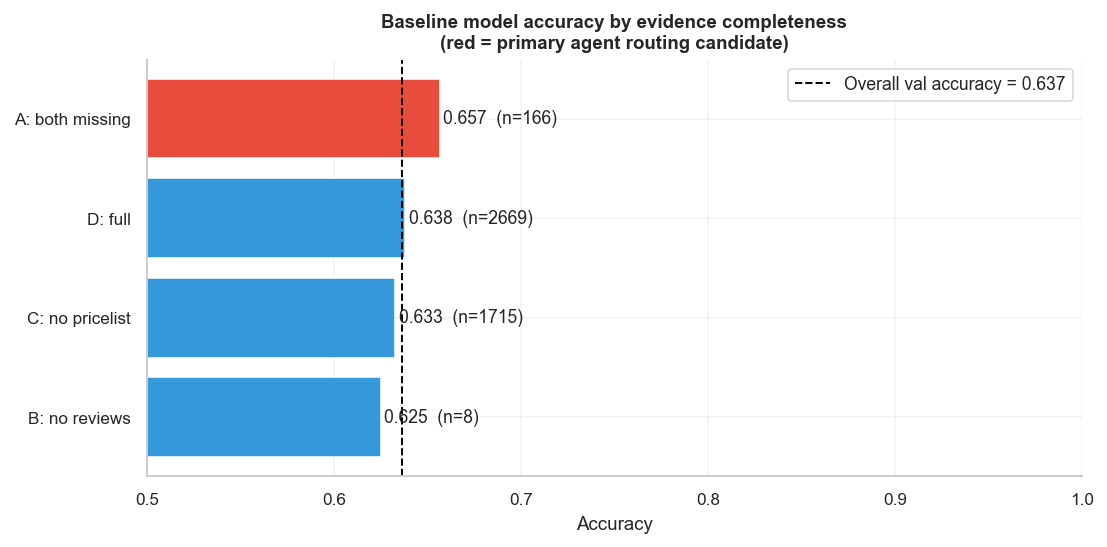

Saved → eda_reports/fig10_routing_accuracy.png


In [33]:
# ── Exp §5: empirical validation of the routing rule ──────────────────────
# Uses the main train/val split — no leakage from §5 splits

# Step 1: add routing category and combined_text to val
df_val_routing = df_val.copy()
df_val_routing[COL_COMBINED_TEXT] = df_val_routing.apply(build_combined_text, axis=1)
df_val_routing['routing']       = df_val_routing.apply(routing_category, axis=1)

# Step 2: add combined_text to train
df_train_routing = df_train.copy()
df_train_routing[COL_COMBINED_TEXT] = df_train_routing.apply(build_combined_text, axis=1)

# Step 3: fit a fresh pipeline on train — do not reuse pipe_binary or pipe_3class
pipe_routing = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=50_000, ngram_range=(1, 2),
                              sublinear_tf=True, min_df=3)),
    ('clf',   LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced',
                                 random_state=RANDOM_STATE, solver='lbfgs'))
])
pipe_routing.fit(df_train_routing[COL_COMBINED_TEXT].values,
                 df_train_routing[COL_RELEVANCE].values)

# Step 4: predict on val and measure accuracy by routing category
df_val_routing['pred']    = pipe_routing.predict(df_val_routing['combined_text'].values)
df_val_routing['correct'] = (df_val_routing['pred'] == df_val_routing[COL_RELEVANCE]).astype(int)

routing_acc = (
    df_val_routing
    .groupby('routing')['correct']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'accuracy', 'count': 'n_val'})
    .sort_values('accuracy')
)

print('Baseline accuracy by routing category (main val split, no leakage):')
print(routing_acc.round(4).to_string())

# Step 5: compute gap
if 'A: both missing' in routing_acc.index and 'D: full' in routing_acc.index:
    acc_A   = routing_acc.loc['A: both missing', 'accuracy']
    acc_D   = routing_acc.loc['D: full',         'accuracy']
    acc_gap = acc_D - acc_A
    n_A     = routing_acc.loc['A: both missing', 'n_val']
    print(f'\nAccuracy gap (D: full − A: both missing): {acc_gap:+.4f}')
    print(f'  n_val for category A: {n_A} '
          f'{"— too small for reliable estimate" if n_A < 30 else ""}')
    if acc_gap > 0:
        print('→ Model underperforms on category A: agent routing is empirically justified.')
    else:
        print('→ Model does NOT underperform on category A: '
              'field presence alone does not predict model failure.')
        print('  Agent routing criteria should be based on confidence scores (Stage 3).')

# Step 6: visualise
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E74C3C' if cat == 'A: both missing' else '#3498DB'
          for cat in routing_acc.index]
bars = ax.barh(routing_acc.index, routing_acc['accuracy'],
               color=colors, edgecolor='white')
for bar, (cat, row) in zip(bars, routing_acc.iterrows()):
    ax.text(row['accuracy'] + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{row['accuracy']:.3f}  (n={int(row['n_val'])})",
            va='center', fontsize=9)

overall_acc = df_val_routing['correct'].mean()
ax.axvline(overall_acc, color='black', linestyle='--', linewidth=1,
           label=f'Overall val accuracy = {overall_acc:.3f}')
ax.legend(fontsize=9)
ax.set_xlim(0.5, 1.0)
ax.set_title('Baseline model accuracy by evidence completeness\n'
             '(red = primary agent routing candidate)', fontweight='bold')
ax.set_xlabel('Accuracy')
sns.despine()
plt.tight_layout()
fig.savefig(EDA_REPORTS_DIR / 'fig10_routing_accuracy.png', bbox_inches='tight')
plt.show()
print('Saved → eda_reports/fig10_routing_accuracy.png')

> **§6 Decision — agent routing:**
>
> Exp §6 shows that category A (both fields missing) yields accuracy = 0.6566, which is **higher** than category D (full evidence, accuracy = 0.6396). The gap D − A = -0.0171 invalidates the hypothesis that missing fields predict model failure. 
>
> Category B (no reviews) has n\_val = 8 in the current split — too small for any reliable conclusion.
>
> The likely explanation is distributional: category A rows are disproportionately irrelevant (≈48% class 0 vs ≈40% in D), making them structurally easier for the classifier. Query, name, and rubric fields provide sufficient signal even without reviews or pricelist.
>
> **Revised routing decision:** We do not route based on field presence. Agent routing criteria will be defined empirically in Stage 3 based on model confidence scores after Baseline training. The `needs_agent` flag in the artefacts is reserved for this purpose and will be populated post-hoc. Routing categories (A/B/C/D) are retained as descriptive metadata for error analysis.

## 7. EDA Summary & decisions log

In [34]:
# 8. EDA Summary

def _load_artifact(name: str) -> pd.DataFrame:
    return pd.read_parquet(Path(PROCESSED_DATA_DIR) / name)

_train = _load_artifact('train_baseline.parquet')
_val   = _load_artifact('val_baseline.parquet')
_eval  = _load_artifact('eval_baseline.parquet')
_ood   = _load_artifact('rel_minus_baseline.parquet')

summary = {
    'Total rows after cleaning':       len(df),
    'Noisy duplicates removed':        len(NOISE_INDICES),
    'Class 0 (IRRELEVANT)':            int((df[COL_RELEVANCE] == 0.0).sum()),
    'Class 0.1 (REL_MINUS)':           int((df[COL_RELEVANCE] == 0.1).sum()),
    'Class 1 (RELEVANT)':              int((df[COL_RELEVANCE] == 1.0).sum()),
    'reviews_summarized missing':      int((~df['has_reviews']).sum()),
    'pricelist_summarized missing':    int((~df['has_pricelist']).sum()),

    '--- DECISIONS ---':               '---',

    'Q1: classes in baseline':         '2 (0 and 1); class 0.1 excluded from all splits',

    'Q1: class 0.1 strategy':          (
        'B3 — exclude (Exp C); '
        'saved separately as rel_minus_baseline.parquet'
    ),

    'Q1: evidence for binary task':    (
        'Exp A macro-F1 = 0.282 (near-uniform confusion); '
        'Exp B macro-F1 = 0.290 (≈ random baseline)'
    ),

    'Q2: split rule':                  (
        '70/15/15 stratified split; '
        'binary-only labels in all subsets'
    ),

    'Q2: metric':                      (
        'Primary: Accuracy on {0,1}; '
        'Secondary: macro-F1'
    ),

    'Q3: agent routing':               (
        'Field presence does not predict model failure '
        '(Δ D−A = -0.0171; Exp §6); '
        'what needs agent will be assigned via confidence threshold in Stage 3'
    ),

    'Q3: missing field handling':      (
        'Placeholder text used: '
        '"No reviews." / "No price list."'
    ),

    '--- BASELINE ARTEFACTS ---':      '---',

    'train_baseline.parquet':          (
        f'{len(_train):,} rows | '
        f'classes {set(_train[TARGET].unique().tolist())} | '
        '70% of binary rows | '
        f'columns: {", ".join(_train.columns)}'
    ),
    'val_baseline.parquet':            (
        f'{len(_val):,} rows | '
        f'classes {set(_val[TARGET].unique().tolist())} | '
        '15% of binary rows | '
        f'columns: {", ".join(_val.columns)} | '
        'used for model selection'
    ),
    'eval_baseline.parquet':           (
        f'{len(_eval):,} rows | '
        f'classes {set(_eval[TARGET].unique().tolist())} | '
        '15% of binary rows | '
        f'columns: {", ".join(_eval.columns)} | '
        'LOCKED — final evaluation only'
    ),
    'rel_minus_baseline.parquet':      (
        f'{len(_ood):,} rows | '
        f'classes {set(_ood[TARGET].unique().tolist())} | '
        'excluded from training | '
        f'columns: {", ".join(_ood.columns)} | '
        'used for OOD analysis in Stage 3'
    ),
    'Label balance (train)':           (
        f'Irrelevant (0): {int((_train[TARGET] == 0).sum()):,} '
        f'({(_train[TARGET] == 0).mean()*100:.1f}%) | '
        f'Relevant (1): {int((_train[TARGET] == 1).sum()):,} '
        f'({(_train[TARGET] == 1).mean()*100:.1f}%)'
    ),
    'Label balance (val)':             (
        f'Irrelevant (0): {int((_val[TARGET] == 0).sum()):,} '
        f'({(_val[TARGET] == 0).mean()*100:.1f}%) | '
        f'Relevant (1): {int((_val[TARGET] == 1).sum()):,} '
        f'({(_val[TARGET] == 1).mean()*100:.1f}%)'
    ),
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=['Item', 'Value']
)

# display

styled_summary = (
    summary_df.style
    .hide(axis='index')
    .set_caption("Table 4. EDA Summary and Experimental Decisions")
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-size', '14pt'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('padding', '10px 0')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#f2f2f2'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('border-bottom', '1.5px solid black'),
                ('padding', '6px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '6px'),
                ('vertical-align', 'top'),
                ('border-bottom', '0.5px solid #d9d9d9'),
                ('white-space', 'pre-wrap')
            ]
        },
    ])
    .set_properties(subset=['Item'], **{
        'font-weight': 'bold',
        'width': '30%'
    })
    .set_properties(subset=['Value'], **{
        'width': '70%'
    })
)

display(styled_summary)

summary_df.to_csv(
    EDA_REPORTS_DIR / 'table3_eda_summary.csv',
    index=False
)

print('\nSaved → eda_reports/table3_eda_summary.csv')

Item,Value
Total rows after cleaning,35089
Noisy duplicates removed,5
Class 0 (IRRELEVANT),14504
Class 0.1 (REL_MINUS),4703
Class 1 (RELEVANT),15882
reviews_summarized missing,1539
pricelist_summarized missing,14464
--- DECISIONS ---,---
Q1: classes in baseline,2 (0 and 1); class 0.1 excluded from all splits
Q1: class 0.1 strategy,B3 — exclude (Exp C); saved separately as rel_minus_baseline.parquet



Saved → eda_reports/table3_eda_summary.csv
